# Lab Sheet 11

In [2]:
from header import *

Exercise 1.1

In [8]:
def mandelbrot_test(c, maxiter=100):
    """
    Test if a point c is in the Mandelbrot set.  Return 1 if it is, 0 otherwise.
    The function maps efficiently over numpy arrays.
    """
    z = 0 * c  # array of zeros of the same shape as c
    m = z + 1  # array of ones of the same shape as c
    for k in range(maxiter):
        # Throughout this loop, m is an array of 1s and 0s and z is an array of complex numbers
        # An entry in m is 1 if the iteration starting with the corresponding c has 
        # not yet escaped from the circle of radius 2, and 0 otherwise.
        # The corresponding entry in z is the current value of the iteration if m = 1,
        # and 10 if m = 0.
        z = m * (z**2 + c) + 10 * (1 - m)
        m = (abs(z) <= 2)*1
    return m

n = 1000
xs = np.linspace(-2.0, 0.4, n+1).reshape(1, n+1) # row vector of real parts
ys = np.linspace(-1.2, 1.2, n+1).reshape(n+1, 1) # column vector of imaginary parts
cs = xs + 1j*ys # broadcast sum gives a matrix of complex numbers
ms = mandelbrot_test(cs, 100)

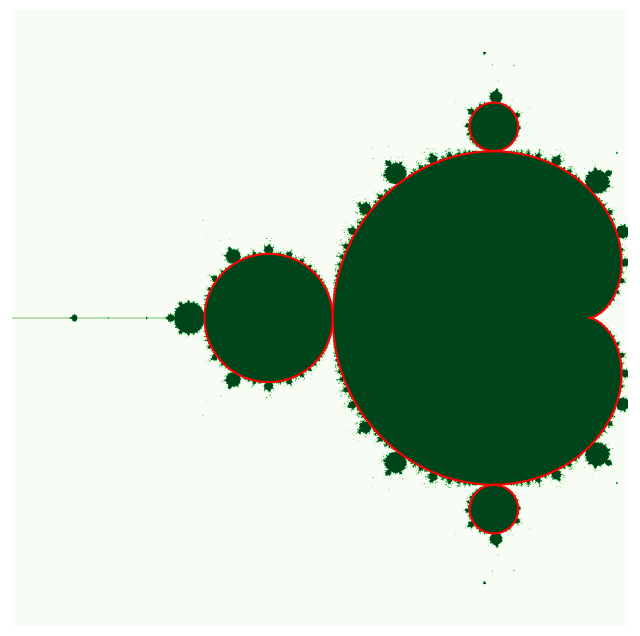

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.axis('off')
ax.axis('equal')
ax.imshow(ms, cmap='Greens', extent=(-2, 0.4, -1.2, 1.2))
ts = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(ts)/2-np.cos(2*ts)/4,np.sin(ts)/2-np.sin(2*ts)/4, 'r')
ax.plot(np.cos(ts)/4-1,np.sin(ts)/4,'r')
ax.plot(-0.1225+0.0945*np.cos(ts), 0.7449+0.0945*np.sin(ts),'r')
ax.plot(-0.1225+0.0945*np.cos(ts),-0.7449+0.0945*np.sin(ts),'r')



Exercise 1.2

In [27]:
def show_curve(n, ax, c):
    xs, ys = np.meshgrid(np.linspace(-3,3,200), np.linspace(-3,3,200))
    zs = (np.abs(xs)**n + np.abs(ys)**n)/n**(n/2)
    ax.contour(xs,ys,zs,[1],colors=[c])

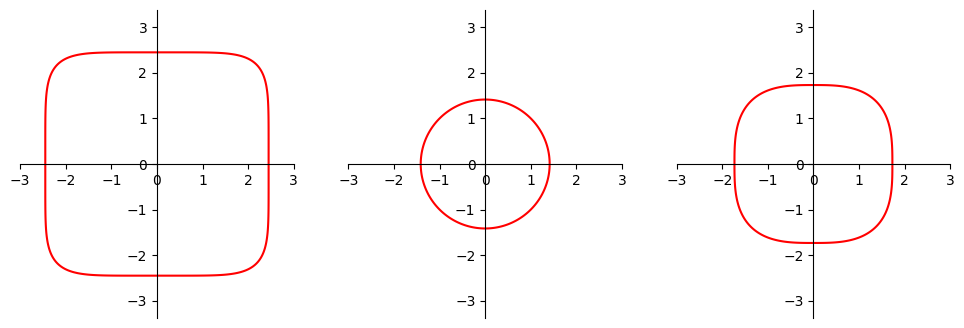

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
show_curve(6, ax[0], 'r')
show_curve(2, ax[1], 'r')
show_curve(3, ax[2], 'r')
for i in range(3):
    ax[i].axis('equal')
    fix_axes(ax[i])



<Axes: >

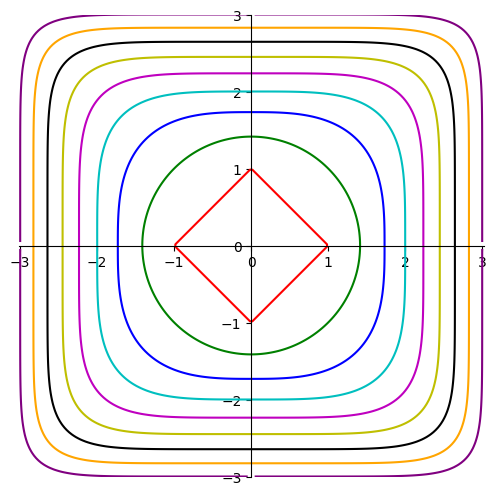

In [29]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.axis('equal')
cols = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'orange', 'purple']
for n in range(1,10):
    show_curve(n, ax, cols[n-1])
fix_axes(ax)

Exercise 1.3

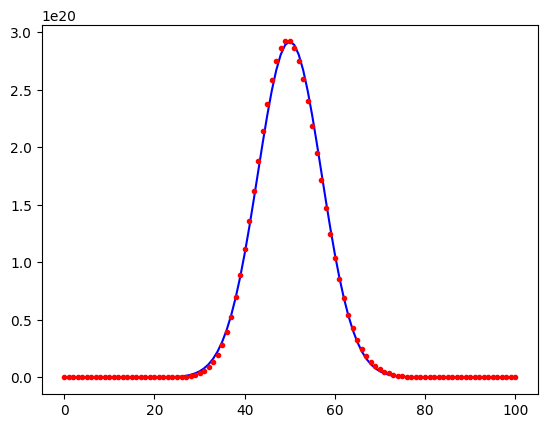

In [48]:
ns = np.arange(101)
ys = [1]
for n in range(1,101):
    ys.append(ys[-1]*50/n)
zs = ys[50] * np.exp(-(ns-50)**2/100)
plt.plot(ns, zs, 'b-')
plt.plot(ns, ys, 'r.')


Exercise 1.4

In [90]:
zeta = sp.functions.special.zeta_functions.zeta
f = lambda t: sp.re(zeta(0.5+1j*t))
g = lambda t: sp.im(zeta(0.5+1j*t))

<Axes: >

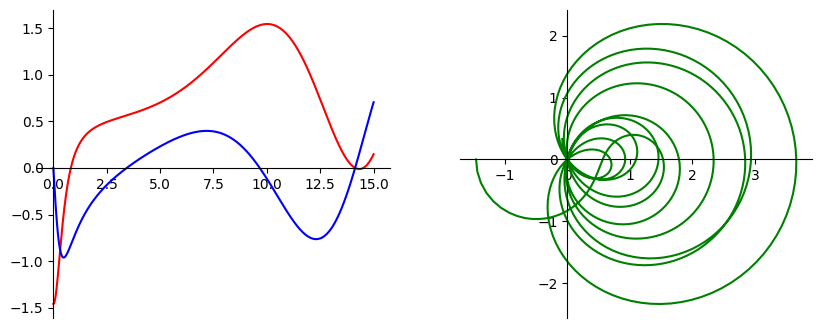

In [89]:
ts0 = np.linspace(0, 15, 1000)
zs0 = np.array([zeta(0.5 + 1j*t).evalf() for t in ts0]).astype(complex)
ts1 = np.linspace(0, 50, 1000)
zs1 = np.array([zeta(0.5 + 1j*t).evalf() for t in ts1]).astype(complex)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(ts,np.real(zs0),'r-')
ax[0].plot(ts,np.imag(zs0),'b-')
ax[1].plot(np.real(zs1),np.imag(zs1),'g-')
fix_axes(ax[0])
fix_axes(ax[1])


<Axes: >

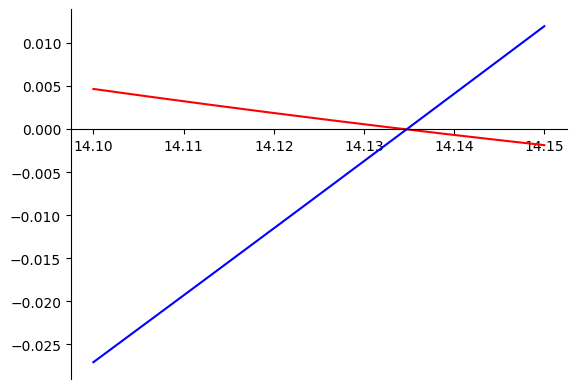

In [87]:
ts = np.linspace(14.1, 14.15, 1000)
zs = np.array([zeta(0.5 + 1j*t).evalf() for t in ts]).astype(complex)
plt.plot(ts,np.real(zs),'r-')
plt.plot(ts,np.imag(zs),'b-')
fix_axes()


Exercise 1.4

In [92]:
x = sp.symbols('x')
y = sp.exp(-1/x)

In [98]:
display(sp.simplify(sp.diff(y,x)))
display(sp.simplify(sp.diff(y,x,2)))
display(sp.simplify(sp.diff(y,x,3)))
display(sp.simplify(sp.diff(y,x,4)))
display(sp.simplify(sp.diff(y,x,5)))

exp(-1/x)/x**2

(1 - 2*x)*exp(-1/x)/x**4

(6*x**2 - 6*x + 1)*exp(-1/x)/x**6

(-24*x**3 + 36*x**2 - 12*x + 1)*exp(-1/x)/x**8

(120*x**4 - 240*x**3 + 120*x**2 - 20*x + 1)*exp(-1/x)/x**10

In [96]:
p = [sp.simplify(sp.diff(y,x,k) * x**(2*k)/y) for k in range(10)]
for k in range(10):
    display(Latex("$p_{" + str(k) + "}(x) = " + sp.latex(p[k]) + "$"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<Axes: >

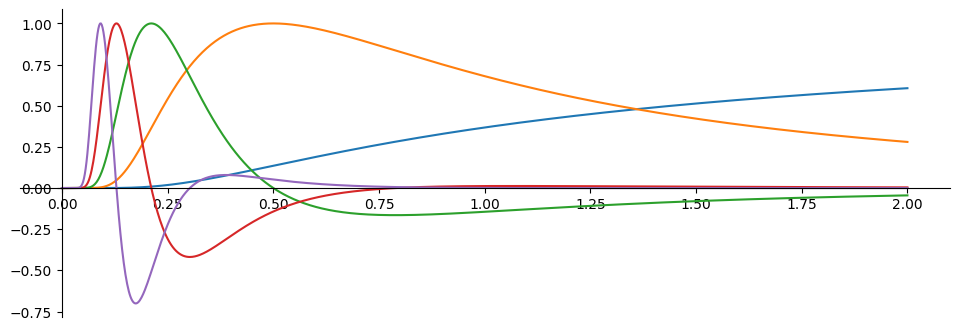

In [149]:
fig, ax = plt.subplots(figsize=(12, 4))
xs = np.linspace(1e-6, 2, 1000)
ax.plot(xs, sp.lambdify(x,y,'numpy')(xs))
for k in range(1,5):
    yk = sp.diff(y,x,k)
    yk_fun = sp.lambdify(x, yk, 'numpy')
    ys = yk_fun(xs)
    ys = ys / np.max(ys)
    ax.plot(xs, ys)
fix_axes(ax)


<Axes: >

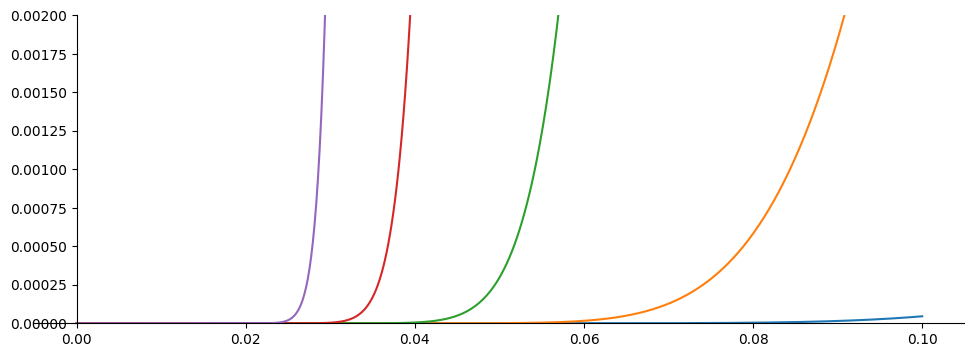

In [151]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_ylim(0,0.002)
xs = np.linspace(1e-6, 0.1, 1000)
for k in range(5):
    yk = sp.diff(y,x,k)
    yk_fun = sp.lambdify(x, yk, 'numpy')
    ys = yk_fun(xs)
    ax.plot(xs, ys)
fix_axes(ax)


In [152]:
del x, y, p

Exercise 1.5

In [164]:
COSH = lambda x: (sp.exp(x) + sp.exp(-x))/2

In [165]:
x, t = sp.symbols('x t')
q = sp.sqrt(2)
p = sp.log(3 + 2*q)
r = x - 4*t
s = q * (x - 8*t)
T = 32 * COSH(2*r-p) + 16 * COSH(2*s-p) + 16
B = 4*(1+q) * COSH(r)*COSH(s) + (4*q-8)*sp.exp(r+s)
phi = [
 2*COSH(r)**(-2),
 4*COSH(s)**(-2),
 2*COSH(r-p)**(-2),
 4*COSH(s-p)**(-2),
 T/B**2
]
phi_fun = sp.lambdify((x,t),phi,'numpy')

K = lambda u: sp.diff(u,t) + sp.diff(u,x,3) + 6 * u * sp.diff(u,x)

In [167]:
[sp.simplify(K(phi[k])) for k in range(5)]

[0, 0, 0, 0, 0]

In [163]:
phi[4]

(16*cosh(2*sqrt(2)*(-8*t + x) - log(2*sqrt(2) + 3)) + 32*cosh(8*t - 2*x + log(2*sqrt(2) + 3)) + 16)/((-8 + 4*sqrt(2))*exp(-4*t + x + sqrt(2)*(-8*t + x)) + (4 + 4*sqrt(2))*cosh(sqrt(2)*(-8*t + x))*cosh(4*t - x))**2